# DATA 30100  Fall 2025

# Homework 2: Computational probability and inference (50 points)

Please complete this notebook by filling in the cells provided.

The solved homework should be uploaded to Canvas as an .ipynb file. DO NOT put your answers in more than one file or use a different file extension.

Make sure to RUN ALL CELLS IN YOUR NOTEBOOK before submitting.  All of your answers should be printed and easy for the instructor to find if you want full credit for your work.

You should work independently unless it is clearly allowed to collaborate.

Homework 2 is due on **Thursday, October 30, at 9:00am**. Late work will not be accepted.  

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter('ignore', FutureWarning)

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

## 1. Buffon Alternative (15 points)

Recall the Buffon's needle problem we discussed in Lecture 5. Here we generalize it to dropping triangles.

**The problem:** Find the probability that an equilateral triangle with each side equal to L will land on a line, given a floor with equally spaced parallel lines a distance D apart. 

**Question 1.** Write a function that has three arguments (number of simulations, the length of the traingle side L, the distance between lines D) and returns the estimated value of the probility of interest.

In [ ]:
import random
import math


def simulate_buffons_triangle(num_sim, side_length, line_distance):
    """
    Simulates Buffon's triangle problem.

    Args:
        num_sim: The number of simulations (number of triangles)
        side_length: The length of triangle side
        line_distance: The distance between parallel lines

    Returns:
        The estimated value of probability
    """
    crossing = 0

    # Circumradius of the triangle
    R = side_length / (math.sqrt(3))

    for num in range(num_sim):
        # Randomly determine the position and angle of the triangle
        # y is the distance from the centroid of the triangle to the nearest line
        # x is the angle of the triangle
        y = random.uniform(0, line_distance/2)
        x = random.uniform(0, math.pi / 3)
        

        y1 = R * math.sin(x)
        y2 = R * math.sin(x + (2 * math.pi / 3))
        y3 = R * math.sin(x + (4 * math.pi / 3))

        # Find the largest y value among the three vertices
        max_y = max(y1, y2, y3)

        # Check if the triangle crosses a line
        if y <= max_y:
            crossing += 1

    estimated_probability = crossing / num_sim
    return estimated_probability

# Example usage
num_simulations = 1000000
side_length = 1.0
line_distance = 1.0
probability = simulate_buffons_triangle(num_simulations, side_length, line_distance)
print(f"Estimated Probability of Triangle Crossing a Line: {probability}")

Estimated Probability of Triangle Crossing a Line: 0.806645


**Question 2.** Run simulations where L is fixed and D varies to determine how the probability varies with D. Similarly, run simulations where D is fixed and L varies to determine how the probability varies with L. Comment on your findings.

In [ ]:
# Probability with varies D
nsim = 1000000
L = 1.0
varD = np.linspace(1, 10, 10)
estimated_p_varD = []

for d in varD:
    prob1 = simulate_buffons_triangle(nsim, L, d)
    estimated_p_varD.append(prob1)

varD_result = pd.DataFrame({
    'D': varD,
    'Estimated Probability': estimated_p_varD
})

print('Result of estimated probability of triangle crossing a line with varies D:')
print(varD_result)

# Probability with varies L
varL = np.linspace(0.2, 2.0, 10)
D = 1.0
estimated_p_varL = []
for l in varL:
    prob2 = simulate_buffons_triangle(nsim, l, D)
    estimated_p_varL.append(prob2)

varL_result = pd.DataFrame({
    'L': varL,
    'Estimated Probability': estimated_p_varL
})
print('Result of estimated probability of triangle crossing a line with varies L:')
print(varL_result)

Result of estimated probability of triangle crossing a line with varies D:
      D  Estimated Probability
0   1.0               0.807453
1   2.0               0.403443
2   3.0               0.268591
3   4.0               0.200706
4   5.0               0.161453
5   6.0               0.134833
6   7.0               0.115381
7   8.0               0.100659
8   9.0               0.089651
9  10.0               0.080470
Result of estimated probability of triangle crossing a line with varies L:
     L  Estimated Probability
0  0.2               0.161098
1  0.4               0.323237
2  0.6               0.484420
3  0.8               0.645452
4  1.0               0.807110
5  1.2               0.920458
6  1.4               0.974124
7  1.6               0.996536
8  1.8               1.000000
9  2.0               1.000000


*Answer here:*

**Question 3.**  The solution for the needle problem is: $$\frac{2}{\pi}\frac{L}{D}$$

Determine the formula for the triangle problem from simulations.

In [ ]:
# Suppose the formula is C * (L/D)

varD_result['C_Value'] = varD_result['Estimated Probability'] * varD_result['D'] / L
print(varD_result)
C1_Avg = varD_result['C_Value'].mean()
print(f'\nAverage C Value with different D: {C1_Avg}' )


      D  Estimated Probability   C_Value
0   1.0               0.807453  0.807453
1   2.0               0.403443  0.806886
2   3.0               0.268591  0.805773
3   4.0               0.200706  0.802824
4   5.0               0.161453  0.807265
5   6.0               0.134833  0.808998
6   7.0               0.115381  0.807667
7   8.0               0.100659  0.805272
8   9.0               0.089651  0.806859
9  10.0               0.080470  0.804700

Average C Value with different D: 0.8063697


*Answer here:*

# 2. Possum metrology (20 points) 

The data for this exercise were collected in Australia and New Guinea and represent various measurements of possum dimensions of 102 animals caught at 7 locations in Victoria, New South Wales, and Queensland in October and November of 1993. Source of data: 

Lindenmayer, D. B., Viggers, K. L., Cunningham, R. B., and Donnelly, C. F. 1995. Morphological variation among columns of the mountain brushtail possum, Trichosurus caninus Ogilby (Phalangeridae: Marsupiala). Australian Journal of Zoology 43: 449-458. 

Variables in the dataset:

- site: one of seven locations where possums were trapped. The sites were, in order, Cambarville, Bellbird, Whian Whian, Byrangery, Conondale, Allyn River and Bulburin
- pop:  a factor which classifies the sites as Vic (for Victoria) and other (New South Wales or Queensland)
- sex: a factor with levels f (female), m (male)
- age
- head_l:  head length
- skull_w:  skull width
- total_l: total length
- tail_l: tail length

We believe that the units for `age` is  years, for `head_l`, `skull_w` and `tail_l` are mm; possums are about 20 inches long so let's assume that `total_l` is in cm.  


In [70]:
# read the data
p_df = pd.read_csv("possum.csv")
p_df.head()

,site,pop,sex,age,head_l,skull_w,total_l,tail_l
0,1,Vic,m,8.0,94.1,60.4,89.0,36.0
1,1,Vic,f,6.0,92.5,57.6,91.5,36.5
2,1,Vic,f,6.0,94.0,60.0,95.5,39.0
3,1,Vic,f,6.0,93.2,57.1,92.0,38.0
4,1,Vic,f,2.0,91.5,56.3,85.5,36.0


In [38]:
# some data summaries
p_df.describe()

,site,age,head_l,skull_w,total_l,tail_l
count,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000
mean,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615
std,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518
min,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000
25%,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000
50%,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000
75%,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000
max,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000


**Question 1.** Produce an adequately-labeled scatterplot of total length (y axis) vs. age (x axis). Explain why the plot has prominent vertical lines.

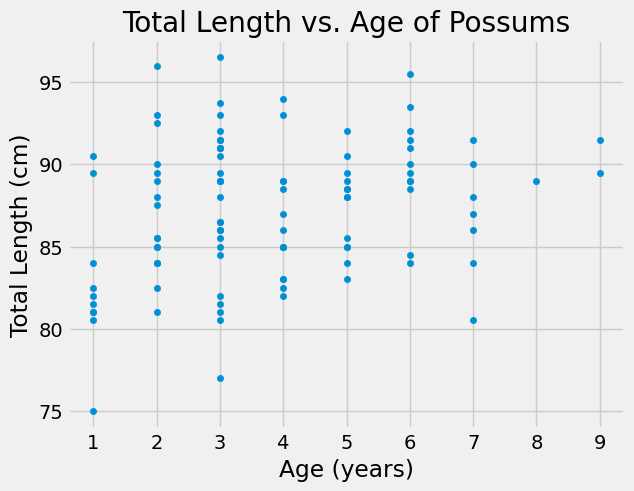

In [40]:
# code here
p_df.plot(kind='scatter', x='age', y='total_l')
plt.title('Total Length vs. Age of Possums')
plt.xlabel('Age (years)')
plt.ylabel('Total Length (cm)')
plt.show()

*Answer:* 


**Question 2.** Test for sexual dimorphism in the skull width measurement in the sampled possums.  (Do the male and female possums have different skull widths?)  This should be done using the permutation method. Display the (permutation generated) null distribution of your test statistic and the observed value of the test statistic. Report the p-value for this null hypothesis that the two sexes have the same skull width distribution.

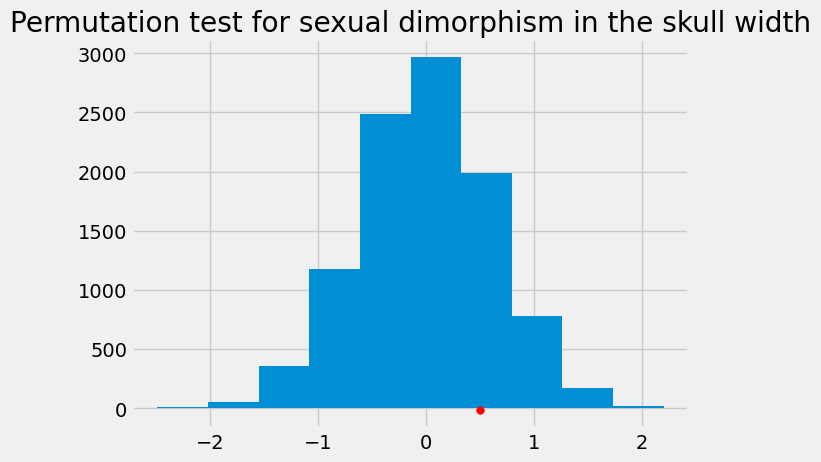


 The test statistic is: 0.5034311856652636

 The P-value is: 0.4128


In [66]:
skulls_m = p_df[p_df['sex'] == 'm']['skull_w']
skulls_f = p_df[p_df['sex'] == 'f']['skull_w']

test_stat = np.mean(skulls_m) - np.mean(skulls_f)

nsim = 10000
difference = np.array([])

for i in range(nsim):
    shuffled_combine = np.random.permutation(np.append(skulls_f, skulls_m))
    shuffled_m = shuffled_combine[0:len(skulls_m)]
    shuffled_f = shuffled_combine[len(skulls_m):len(skulls_m)+len(skulls_f)]
    difference = np.append(difference, np.mean(shuffled_m)-np.mean(shuffled_f))

plt.hist(difference)
plt.scatter(test_stat, -20, color='red', s=30)
plt.title('Permutation test for sexual dimorphism in the skull width')
plt.show()

p_value = np.sum(np.abs(difference)>=np.abs(test_stat))/nsim
print(f'\n The test statistic is: {test_stat}')
print(f'\n The P-value is: {p_value}')

**Question 3.** Similarly to Question 2, test the hypothesis of equality in distributions for the tail lengths of male possums sampled in Victoria (sites 1 and 2) and the tail lengths of male possums sampled outside of Victoria.

This should be done using the permutation method. Display the (permutation generated) null distribution of your test statistics and the observed value of the test statistic. Report the p-value for this null hypothesis that the two groups have the same tail length distribution.

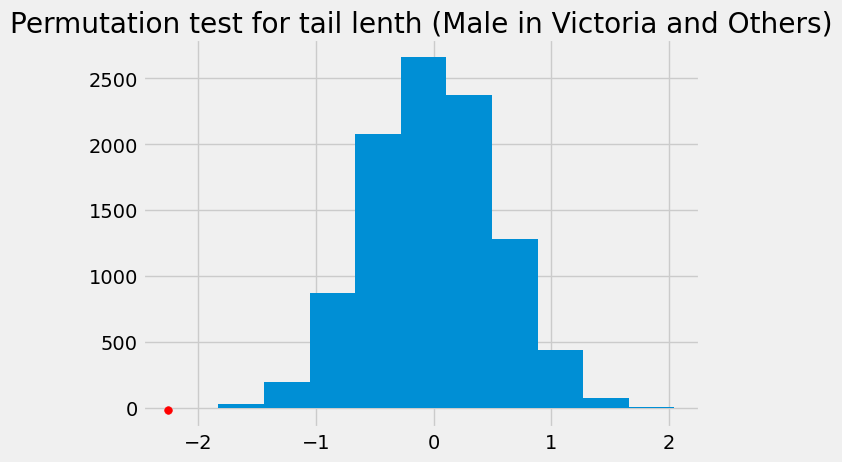


 The test statistic is: -2.2564102564102555

 The P-value is: 0.0


In [80]:
p_df_m = p_df[p_df['sex'] == 'm']

tail_v = p_df_m[p_df_m['site'].isin([1, 2])]['tail_l']
tail_o = p_df_m[p_df_m['site'].isin([1, 2]) == False]['tail_l']

test_stat2 = np.mean(tail_v) - np.mean(tail_o)

nsim = 10000
difference2 = np.array([])

for i in range(nsim):
    shuffled_combine2 = np.random.permutation(np.append(tail_v, tail_o))
    shuffled_v = shuffled_combine2[0:len(tail_v)]
    shuffled_o = shuffled_combine2[len(tail_v):len(tail_v)+len(tail_o)]
    difference2 = np.append(difference2, np.mean(shuffled_v)-np.mean(shuffled_o))

plt.hist(difference2)
plt.scatter(test_stat2, -20, color='red', s=30)
plt.title('Permutation test for tail lenth (Male in Victoria and Others)')
plt.show()

p_value2 = np.sum(np.abs(difference2)>=np.abs(test_stat2))/nsim
print(f'\n The test statistic is: {test_stat2}')
print(f'\n The P-value is: {p_value2}')


**Question 4.** Write code that constructs a 2x2 table that shows the counts of sex (female and male) in the two sites (Victoria and other)

In [89]:
counts = pd.crosstab(p_df['sex'], p_df['pop'])
print(counts)

pop  Vic  other
sex            
f     24     19
m     22     39


**Question 5.** Investigate the hypothesis that the porportion of males to females is equal in the two sites (perform a hypothesis test on the table you constructed in Question 4 using the permutation method). State clearly the null and alternative hypothesis. After you perform the test and report the p-value, briefly talk about the assumptions in your test.

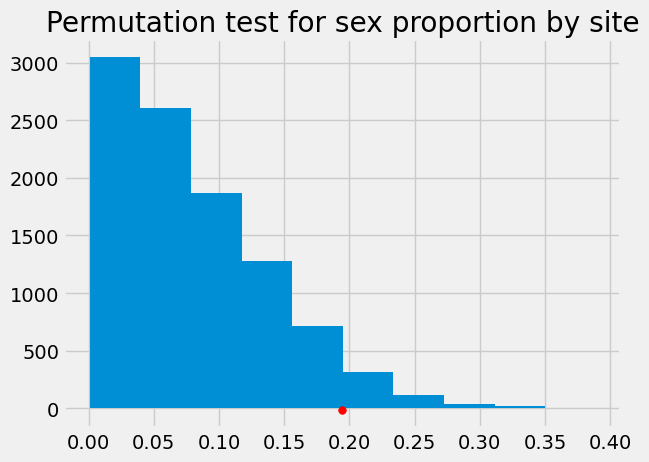


 The test statistic is: 0.19415292353823088

 The P-value is: 0.0729


In [ ]:
def tvd(array1,array2): 
    return sum(abs(array1/sum(array1)-array2/sum(array2)))/2

obs_tvd=tvd(counts.T.iloc[0].values,
          counts.T.iloc[1].values)

nsim = 10000
TVD = np.array([])

for i in range(nsim):
    shuffled_sex = np.random.permutation(p_df['sex'])
    shuffled_counts = pd.crosstab(shuffled_sex, p_df['pop'])
    sim_tvd = tvd(shuffled_counts.T.iloc[0].values,
                  shuffled_counts.T.iloc[1].values)
    TVD = np.append(TVD, sim_tvd)

plt.hist(TVD)
plt.scatter(obs_tvd, -20, color='red', s=30)
plt.title('Permutation test for sex proportion by site')
plt.show()

p_value3 = np.sum(TVD>=obs_tvd)/nsim
print(f'\n The test statistic is: {obs_tvd}')
print(f'\n The P-value is: {p_value3}')


*Answer here:* 

# 3. Multiple Testing (15 points) 

The provided dataset consists of expression measurements for 2,308 genes in four subtypes of small round blood
cell tumors, a type of cancer typically seen in children.  There are 83 subjects in the study.

In [92]:
# read the data
ge_df = pd.read_csv("expression_hwk2.csv")
ge_df.shape

(83, 2309)

In [93]:
ge_df['CancerType'].value_counts()

CancerType
2    29
4    25
3    18
1    11
Name: count, dtype: int64

In this exercise, we restrict our attention to the two sub-types for which the most observations are available: rhabdomyosarcoma (**29 subjects, cancer type coded as 2**) and Burkitt’s lymphoma (**25 subjects, cancer type coded as 4**).

**Question 1.** Test for differential expression between rhabdomyosarcoma and Burkitt’s lymphoma:
- you need to perform 2308 tests and obtain 2308 p-values;
- each test is done using the permutation method;
- the test statistic is the **difference in mean/average expression** between the two cancer types;
- for computational reasons try to do all of them at the same time;
- output should be an array or a list with the 2308 p-values.

Note that the next question will ask about FDR at the 0.001 level, so make sure that you do enough permutations/simulations to be able to tell which p-values are smaller than 0.001.

Show a histogram of the 2308 p-values you calculated.

In [123]:
ge24 = ge_df[ge_df['CancerType'].isin([2,4])].copy()
y = ge24['CancerType'].values
x = ge24.drop(columns=['CancerType']).values
obs_stats = np.mean(x[y == 4], axis=0) - np.mean(x[y == 2], axis=0)

nsim = 10000
counts_list = np.array([0] * 2308)

for i in range(nsim):
    shuffled_type = np.random.permutation(y)
    sim_stats = np.mean(x[shuffled_type == 4], axis=0) - np.mean(x[shuffled_type == 2], axis=0)
    counts_list += (np.abs(sim_stats) >= np.abs(obs_stats))

p_values = counts_list/nsim
print(f'We calculated {len(p_values)} p-values')
print(f"There are {np.sum(p_values < 0.05)} genes with p-value < 0.05")
print(f"There are {np.sum(p_values < 0.01)} genes with p-value < 0.01")
print(f"There are {np.sum(p_values < 0.001)} genes with p-value < 0.001")

We calculated 2308 p-values
There are 551 genes with p-value < 0.05
There are 341 genes with p-value < 0.01
There are 176 genes with p-value < 0.001


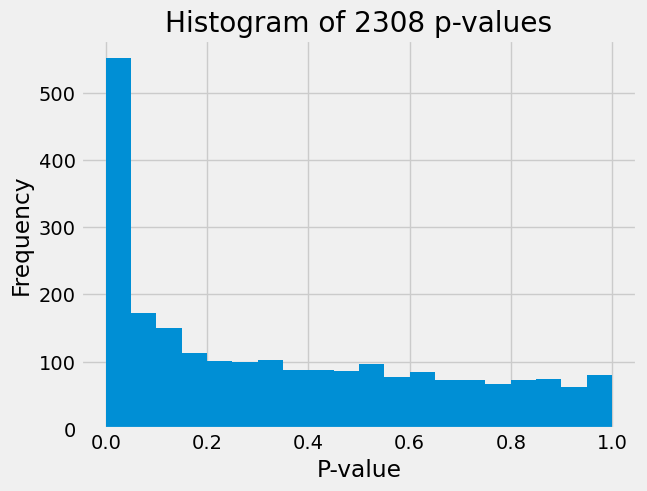

In [ ]:
plt.hist(p_values, bins=np.arange(0, 1.05, 0.05))
plt.title('Histogram of 2308 p-values')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.show()

**Question 2.** Suppose you decide to declare all genes with p-values smaller than 0.001 as **differentially expressed**. How many genes are differentially expressed? What is the **False Discovery Rate (FDR)** you estimate for this set of genes?

In [127]:
alpha = 0.001
R = np.sum(p_values < alpha)

# Assume Lambda = 0.6
m0 = np.sum(p_values > 0.6) / (1.0 - 0.6)

FDR = (m0*alpha)/R
print(f'There are {R} genes are differentially expressed')
print(f'The False Discovery Rate (FDR) is {FDR}')

There are 176 genes are differentially expressed
The False Discovery Rate (FDR) is 0.00828125


*Answer here:* 

**Question 3.** Using Benjamini-Hochberg procedure find the set of genes that is differentially expressed at an FDR=0.03. What is the p-value threshold for this set? How many genes are in this set?

In [131]:
bh_FDR = 0.03

m = len(p_values)
j = np.arange(1, m + 1)
p_values_sorted = np.sort(p_values)

bh_value = bh_FDR * j / m

critical_genes = p_values_sorted <= bh_value
critical_j = np.where(critical_genes)[0]
max_j = critical_j.max()
p_value_max_j = p_values_sorted[max_j]
num_j = max_j + 1

print(f"P-value threshold for this set: {p_value_max_j}")
print(f"There are {num_j} genes in this set.")

P-value threshold for this set: 0.0031
There are 243 genes in this set.


*Answer here:* 